# Poder de Compra do Salário Mínimo (Anos 90 - Hoje)

Nesta análise, vamos baixar os dados nominais do Salário Mínimo e os dados de inflação (IPCA), ambos do Banco Central do Brasil (BCB), e calcular o Salário Mínimo Real ao longo do tempo (descontando a inflação e corrigindo as mudanças de moeda).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import urllib.request
import json
import warnings
warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Coleta de Dados do Banco Central (SGS)
Usamos a API do Banco Central para coletar:
- **Série 1619**: Salário Mínimo Nominal
- **Série 433**: IPCA (Índice Nacional de Preços ao Consumidor Amplo) - variação mensal

In [ ]:
def fetch_bcb(series_id, start_date='01/01/1990', end_date='31/12/2026'):
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_id}/dados?dataInicial={start_date}&dataFinal={end_date}&formato=json'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    data = json.loads(response.read().decode('utf-8'))
    df = pd.DataFrame(data)
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df['valor'] = pd.to_numeric(df['valor'])
    return df.set_index('data')

print('Coletando Salário Mínimo...')
sm = fetch_bcb(1619)
sm.columns = ['salario_minimo_nominal']

print('Coletando IPCA...')
ipca = fetch_bcb(433)
ipca.columns = ['ipca_mensal']

df = sm.join(ipca, how='inner')
display(df.head())
display(df.tail())

Coletando Salário Mínimo...
Coletando IPCA...


,salario_minimo_nominal,ipca_mensal
data,,
1990-02-01,2004.37,75.73
1990-03-01,3674.06,82.39
1990-04-01,3674.06,15.52
1990-05-01,3674.06,7.59
1990-06-01,3857.76,11.75


,salario_minimo_nominal,ipca_mensal
data,,
2026-01-01,1621.0,0.33
2026-02-01,1621.0,0.70
2026-03-01,1621.0,0.88
2026-04-01,1621.0,0.67
2026-05-01,1621.0,0.58


## 2. Ajuste de Moeda e Cálculo do Salário Mínimo Real
Antes do Plano Real (Julho/1994), o Brasil passou por hiperinflação e mudanças de moeda (Cruzeiro, Cruzado Novo, Cruzeiro Real). 
Precisamos primeiro converter todos os valores nominais para a paridade do Real (R$), e somente depois multiplicar pela inflação acumulada para trazer a valor presente.

In [ ]:
df = df.sort_index(ascending=True)

# Conversão de moedas pré-Real para a paridade do Real (R$):
# Antes de 01/08/1993: Cruzados Novos / Cruzeiros -> divide por 2.750.000 (1000 * 2750)
# De 01/08/1993 a 30/06/1994: Cruzeiros Reais -> divide por 2.750
def convert_to_reais(row):
    if row.name < pd.to_datetime('1993-08-01'):
        return row['salario_minimo_nominal'] / 2750000.0
    elif row.name < pd.to_datetime('1994-07-01'):
        return row['salario_minimo_nominal'] / 2750.0
    else:
        return row['salario_minimo_nominal']

df['salario_minimo_reais_nominais'] = df.apply(convert_to_reais, axis=1)

# Cálculo da inflação acumulada (IPCA)
df['ipca_fator'] = 1 + df['ipca_mensal'] / 100

# Fator que traz o valor do tempo 't' para o momento atual (T)
fator_total = df['ipca_fator'].prod()
df['fator_presente'] = fator_total / df['ipca_fator'].cumprod()

# O salário real é o valor nominal na paridade do Real multiplicado pela inflação acumulada
df['salario_minimo_real'] = df['salario_minimo_reais_nominais'] * df['fator_presente']

# Limpando colunas auxiliares
df = df.drop(columns=['ipca_fator', 'fator_presente'], errors='ignore')

display(df.head())
display(df.tail())

,salario_minimo_nominal,ipca_mensal,salario_minimo_reais_nominais,salario_minimo_real
data,,,,
1990-02-01,2004.37,75.73,0.000729,585.621191
1990-03-01,3674.06,82.39,0.001336,588.551011
1990-04-01,3674.06,15.52,0.001336,509.479754
1990-05-01,3674.06,7.59,0.001336,473.538204
1990-06-01,3857.76,11.75,0.001403,444.934879


,salario_minimo_nominal,ipca_mensal,salario_minimo_reais_nominais,salario_minimo_real
data,,,,
2026-01-01,1621.0,0.33,1621.0,1667.359540
2026-02-01,1621.0,0.70,1621.0,1655.769156
2026-03-01,1621.0,0.88,1621.0,1641.325492
2026-04-01,1621.0,0.67,1621.0,1630.401800
2026-05-01,1621.0,0.58,1621.0,1621.000000


## 3. Visualização com Marcos Temporais
Agora plotamos a evolução correta do poder de compra em valores reais de hoje, marcando os governos e o início do Plano Real.

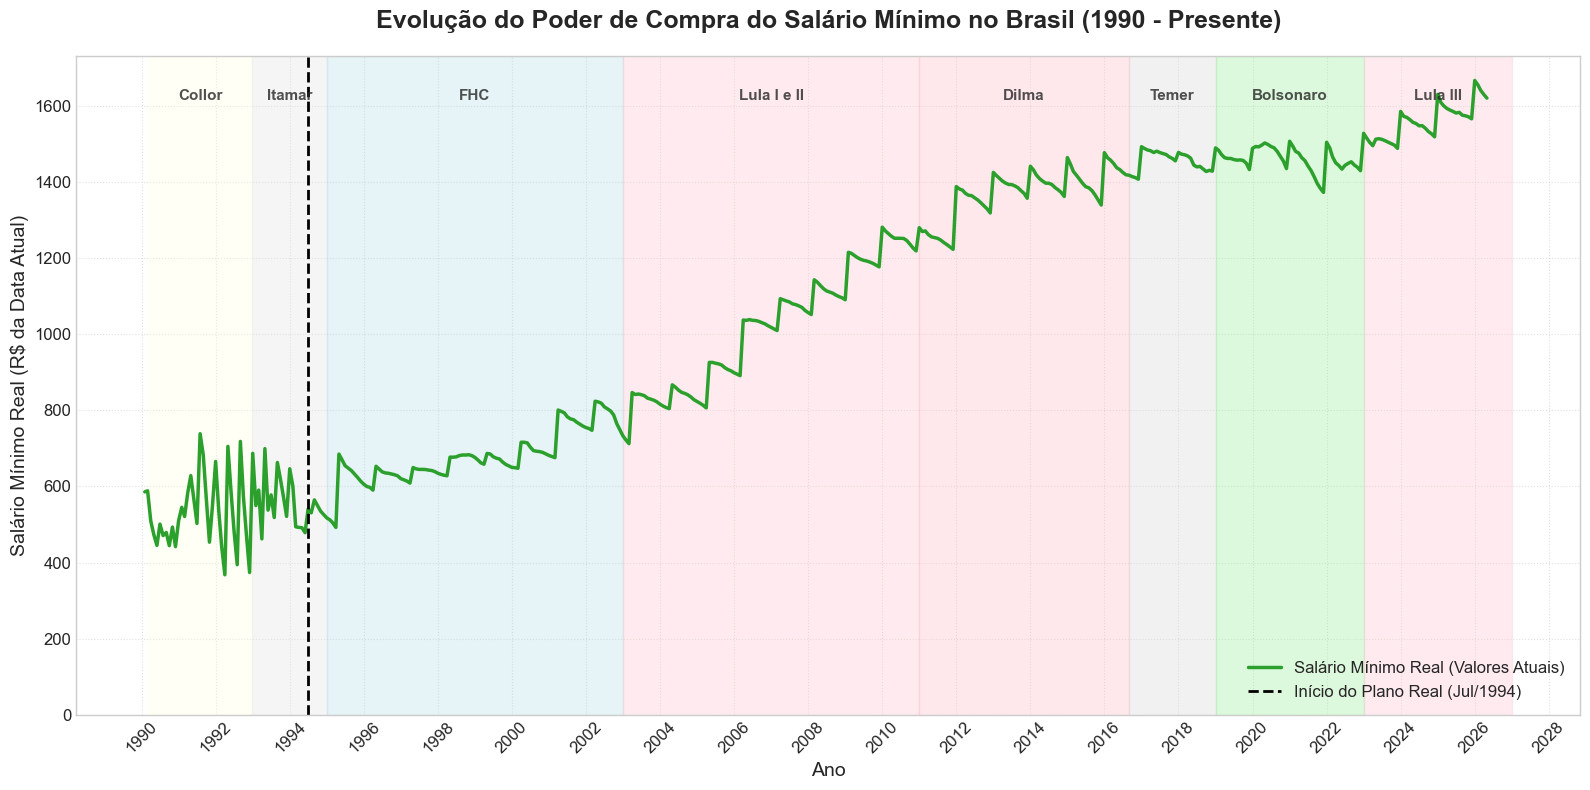

In [ ]:
# Definição dos governos e cores representativas
governos = [
    ('Collor', '1990-03-15', '1992-12-29', '#FFFFE0'),
    ('Itamar', '1992-12-29', '1995-01-01', '#E0E0E0'),
    ('FHC', '1995-01-01', '2003-01-01', '#ADD8E6'),
    ('Lula I e II', '2003-01-01', '2011-01-01', '#FFC0CB'),
    ('Dilma', '2011-01-01', '2016-08-31', '#FFB6C1'),
    ('Temer', '2016-08-31', '2019-01-01', '#D3D3D3'),
    ('Bolsonaro', '2019-01-01', '2023-01-01', '#90EE90'),
    ('Lula III', '2023-01-01', '2026-12-31', '#FFC0CB')
]

fig, ax = plt.subplots(figsize=(16, 8))

# Linha principal do Salário Mínimo Real
ax.plot(df.index, df['salario_minimo_real'], color='#2ca02c', linewidth=2.5, label='Salário Mínimo Real (Valores Atuais)')

# Marcador: Início do Plano Real
plano_real_data = pd.to_datetime('1994-07-01')
ax.axvline(plano_real_data, color='black', linestyle='--', linewidth=2, label='Início do Plano Real (Jul/1994)')

# Adicionar faixas dos governos no fundo
ymin, ymax = ax.get_ylim()
for nome, inicio, fim, cor in governos:
    dt_inicio = pd.to_datetime(inicio)
    dt_fim = pd.to_datetime(fim)
    if dt_inicio > df.index[-1]: continue
    
    dt_fim = min(dt_fim, df.index[-1] + pd.Timedelta(days=365))
    ax.axvspan(dt_inicio, dt_fim, color=cor, alpha=0.3)
    
    # Adicionar nome do governo (ajuste visual na altura)
    meio = dt_inicio + (dt_fim - dt_inicio) / 2
    ax.text(meio, ymax * 0.95, nome, ha='center', va='top', fontsize=11, fontweight='bold', alpha=0.8)

# Ajustes estéticos e de formatação
ax.set_title('Evolução do Poder de Compra do Salário Mínimo no Brasil (1990 - Presente)', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Salário Mínimo Real (R$ da Data Atual)', fontsize=14)
ax.set_xlabel('Ano', fontsize=14)
ax.legend(loc='lower right', fontsize=12)

# Formatação do eixo X (Anos)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

ax.grid(True, linestyle=':', alpha=0.6)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 4. Comparação com Outros Índices de Inflação (INPC e IGP-M)
Para ter uma visão mais completa, vamos verificar qual seria o valor do salário mínimo real se a inflação fosse descontada pelo **INPC** (Índice Nacional de Preços ao Consumidor) e pelo **IGP-M** (Índice Geral de Preços - Mercado).


In [ ]:
print('Coletando INPC...')
inpc = fetch_bcb(188)
inpc.columns = ['inpc_mensal']

print('Coletando IGP-M...')
igpm = fetch_bcb(189)
igpm.columns = ['igpm_mensal']

df_indices = df[['salario_minimo_reais_nominais', 'salario_minimo_real']].copy()
df_indices = df_indices.join(inpc, how='left')
df_indices = df_indices.join(igpm, how='left')

# Preencher NaN com 0 (caso faltem dados em meses isolados)
df_indices['inpc_mensal'] = df_indices['inpc_mensal'].fillna(0)
df_indices['igpm_mensal'] = df_indices['igpm_mensal'].fillna(0)

df_indices['inpc_fator'] = 1 + df_indices['inpc_mensal'] / 100
df_indices['igpm_fator'] = 1 + df_indices['igpm_mensal'] / 100

inpc_total = df_indices['inpc_fator'].prod()
igpm_total = df_indices['igpm_fator'].prod()

df_indices['inpc_presente'] = inpc_total / df_indices['inpc_fator'].cumprod()
df_indices['igpm_presente'] = igpm_total / df_indices['igpm_fator'].cumprod()

df_indices['salario_real_inpc'] = df_indices['salario_minimo_reais_nominais'] * df_indices['inpc_presente']
df_indices['salario_real_igpm'] = df_indices['salario_minimo_reais_nominais'] * df_indices['igpm_presente']

plt.figure(figsize=(14, 7))
plt.plot(df_indices.index, df_indices['salario_minimo_real'], label='Salário Real (IPCA)', linewidth=2, color='tab:blue')
plt.plot(df_indices.index, df_indices['salario_real_inpc'], label='Salário Real (INPC)', linewidth=2, color='tab:orange', linestyle='--')
plt.plot(df_indices.index, df_indices['salario_real_igpm'], label='Salário Real (IGP-M)', linewidth=2, color='tab:green', linestyle='-.')

plt.axvline(x=pd.to_datetime('1994-07-01'), color='gray', linestyle='--', alpha=0.7, label='Plano Real (Jul/1994)')

plt.title('Comparação do Salário Mínimo Real: IPCA vs INPC vs IGP-M (Valores de Hoje)', fontsize=16)
plt.ylabel('Valor em Reais (R$)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Poder de Compra Direto (Cesta Básica e Dólar)
O poder de compra não é apenas uma abstração matemática de inflação, mas sim "quantos produtos consigo comprar". Vamos analisar duas referências chave:
1. **Dólar (Série BCB 3695)**: Valor de câmbio médio mensal (PTAX).
2. **Cesta Básica SP (Série BCB 7483)**: Levantamento do DIEESE para a cidade de São Paulo.


In [ ]:
print('Coletando Dólar...')
dolar = fetch_bcb(3695)
dolar.columns = ['dolar_mensal']

print('Coletando Cesta Básica (SP)...')
# A série pode não cobrir todo o período dos anos 90
cesta = fetch_bcb(7483)
cesta.columns = ['cesta_basica_sp']

df_produtos = df[['salario_minimo_nominal']].copy()
df_produtos = df_produtos.join(dolar, how='left')
df_produtos = df_produtos.join(cesta, how='left')

# Cálculo de quantas cestas básicas o salário compra e quantos dólares
df_produtos['poder_compra_cestas'] = df_produtos['salario_minimo_nominal'] / df_produtos['cesta_basica_sp']
df_produtos['poder_compra_dolar'] = df_produtos['salario_minimo_nominal'] / df_produtos['dolar_mensal']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Gráfico 1: Dólar
ax1.plot(df_produtos.index, df_produtos['poder_compra_dolar'], color='tab:green', linewidth=2)
ax1.set_title('Salário Mínimo convertido em Dólares (US$)', fontsize=14)
ax1.set_ylabel('Valor em Dólares (US$)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.fill_between(df_produtos.index, df_produtos['poder_compra_dolar'], color='tab:green', alpha=0.1)

# Gráfico 2: Cesta Básica
ax2.plot(df_produtos.index, df_produtos['poder_compra_cestas'], color='tab:red', linewidth=2)
ax2.set_title('Poder de Compra: Quantas Cestas Básicas (SP) o Salário Mínimo compra?', fontsize=14)
ax2.set_ylabel('Quantidade de Cestas Básicas', fontsize=12)
ax2.set_xlabel('Data', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.fill_between(df_produtos.index, df_produtos['poder_compra_cestas'], color='tab:red', alpha=0.1)

# Linha de 1 cesta básica
ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='1 Cesta Básica')
ax2.legend()

plt.tight_layout()
plt.show()
